<a href="https://colab.research.google.com/github/Yaminipampana/Customer-Retail-ML-Project/blob/main/MlfinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **CUSTOMER RETAIL MACHINE LEARNING PROJECT**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

**Load Dataset**

In [2]:
df = pd.read_csv("customer_retail csv file.csv")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [4]:
print(df.shape)

(541909, 8)


**Check Dataset Columns**

In [5]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


**SELECT REQUIRED COLUMNS**

In [6]:
df = df[['Quantity', 'UnitPrice', 'Country']]

df.dropna(inplace=True)


**Handle Missing Values**

In [7]:
df.dropna(inplace=True)

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Quantity     0
UnitPrice    0
Country      0
dtype: int64


**Data Preprocessing**

* **ENCODE COUNTRY COLUMN***

In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])

print("\nDataset After Encoding:")
print(df.head())


Dataset After Encoding:
   Quantity  UnitPrice  Country
0         6       2.55       36
1         6       3.39       36
2         8       2.75       36
3         6       3.39       36
4         6       3.39       36


**VISUALIZATION**
* **Customer Distribution Graph**

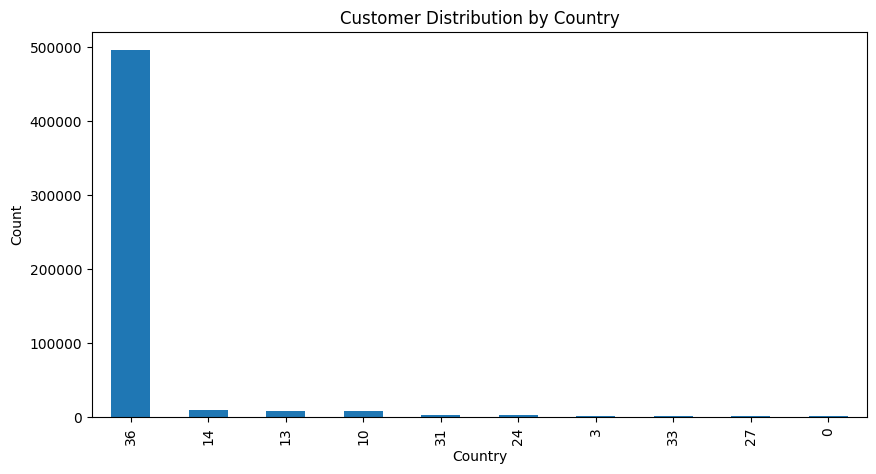

In [9]:
plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

**Split Dataset**

In [10]:
from sklearn.model_selection import train_test_split
X = df[['Quantity', 'UnitPrice']]
y = df['Country']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Logistic Regression**

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_acc)
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.9124024284475282
[[    0     0     0 ...     0   253     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    16     0]
 [    0     0     1 ...     0 98887     0]
 [    0     0     0 ...     0    91     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_acc)
print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.9130851986492222
[[   12     0     0 ...     0   225     0]
 [    0     0     0 ...     0    74     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    16     0]
 [   21     0     1 ...     0 98748     0]
 [    0     0     0 ...     0    91     0]]


In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy:", knn_acc)
print(confusion_matrix(y_test, knn_pred))

Accuracy: 0.9101972652285435
[[   15     0     0 ...     0   225     0]
 [    0     0     0 ...     0    73     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    15     0]
 [   47     0     0 ...     0 98426     0]
 [    0     0     0 ...     0    91     0]]


In [14]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc
]


print("MODEL COMPARISON")

for model, acc in zip(models, accuracies):
    print(model, ":", round(acc*100,2), "%")

MODEL COMPARISON
Logistic Regression : 91.24 %
Decision Tree : 91.31 %
KNN : 91.02 %


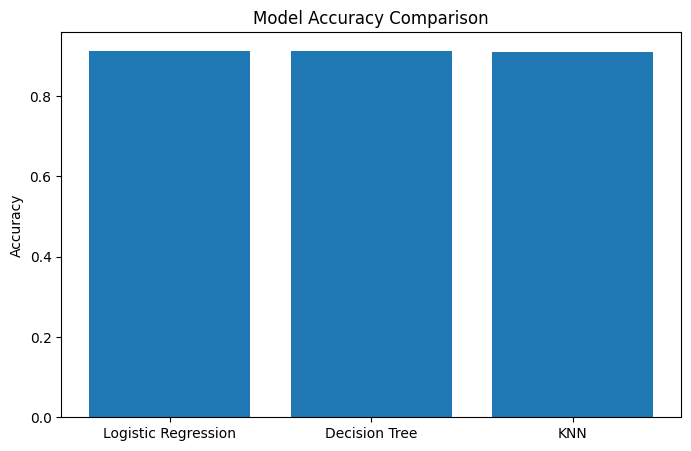

In [15]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracy = [lr_acc, dt_acc, knn_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [16]:
best_model = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("\nBest Model =", best_model)
print("Best Accuracy =", round(best_accuracy*100,2), "%")


Best Model = Decision Tree
Best Accuracy = 91.31 %
